In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(100)

In [9]:
CC, CD, DD = 2, 0, 1  #both conforming, diviation, both defecting

# assuming a symmetric game, payoff matrix symmetrical
def material_utility(player, neighbour, matrix):
        if player == 1 and neighbour == 1:
            return matrix[0]
        elif player == 0 and neighbour == 0:
            return matrix[2]
        else:
            return matrix[1]

def relational_utility(p, q, theta, norm):
        if norm == "conforming":
            return -theta * (p - q) ** 2
        elif norm == "promoting":
            return theta * (p - q)*q
        else:
            raise ValueError("norm must be 'conforming' or 'promoting'")

#difference in utility between 2 actions
def du(u1, u2, q, theta, gamma, s):
     return u1-u2-(1-s)*theta*(1-2*q)+s*gamma*q


In [ ]:
#update functions

#maximise individual utility, no direct imitation of neighbours
def hypothetical_utility(player, action, q):
    if player.neighbours:
        material = sum(material_utility(action, n.on, player.matrix) for n in player.neighbours)
        material /= len(player.neighbours)
    else:
        material = 0.0

    relational = relational_utility(action, q, player.theta, player.norm)

    return material + relational

def rational_update(player):
    q = player.local_cooperation_rate()
    u_defect = hypothetical_utility(player, 0, q)
    u_cooperate = hypothetical_utility(player, 1, q)
    player.next = 1 if u_cooperate > u_defect else 0


#purely imitation, copy action of neighbour with highest utility if higher than the player's
def max_update(player):
        if not player.neighbours:
            player.next = player.on
            return
        best = max(player.neighbours, key=lambda n: n.utility)
        player.next = best.on if best.utility > player.utility else player.on

def norm_update(player):
    q = player.local_cooperation_rate()
    u1 = q * player.CC + (1 - q) * player.CD
    u2 = q * player.CD + (1 - q) * player.DD

    # Difference in total utility
    delta = du(u1, u2, q, player.theta, player.gamma, player.s)

    # Cooperate if du > 0, otherwise defect
    player.next = 1 if delta > 0 else 0

In [ ]:
```python
# Update based on du




```

Then change the `Player(...)` creation inside `Grid` to:

```python
Player(
    theta=theta,
    gamma=gamma,
    s=s,
    CC=CC,
    CD=CD,
    DD=DD,
    update=norm_update
)
```


In [ ]:
class Player:

    def __init__(self, theta, gamma, s, CC, CD, DD, update=norm_update):

        self.neighbours = []

        self.on = 0
        self.next = 0

        self.theta = theta
        self.gamma = gamma
        self.s = s

        # Game payoffs
        self.CC = CC
        self.CD = CD
        self.DD = DD

        # Update rule
        self.update = update

    def local_cooperation_rate(self):

        if not self.neighbours:
            return 0.0

        return sum(
            n.on for n in self.neighbours
        ) / len(self.neighbours)

In [12]:
class Grid:
    def __init__(self, width, height, theta=2, gamma=2, s=0.5, u1=5, u2=2, init_probs=0.2):
        self.width = width
        self.height = height

        self.grid = [
            [
                Player(theta=theta, gamma=gamma, s=s, u1=u1, u2=u2, update=norm_update)
                for x in range(width)
            ]
            for y in range(height)
        ]

        # Random initial state
        for row in self.grid:
            for agent in row:
                agent.on = 1 if rng.random() < init_probs else 0

        self.wire_neighbours()

    def wire_neighbours(self):
        for y in range(self.height):
            for x in range(self.width):

                agent = self.grid[y][x]
                neighbours = []

                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:

                        # Don't include the agent itself
                        if dx == 0 and dy == 0:
                            continue

                        # Periodic boundary conditions
                        nx = (x + dx) % self.width
                        ny = (y + dy) % self.height

                        neighbours.append(self.grid[ny][nx])

                agent.neighbours = neighbours

    def step(self):

        # First: every agent calculates its next action
        # using the CURRENT state of the grid.
        for row in self.grid:
            for agent in row:
                agent.update(agent)

        # Second: apply all updates simultaneously.
        for row in self.grid:
            for agent in row:
                agent.on = agent.next

    def state_array(self):
        return np.array([
            [agent.on for agent in row]
            for row in self.grid
        ])

    def fraction_on(self):
        return self.state_array().mean()

In [13]:
def plot_grid(grid, ax=None, title=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        grid.state_array(),
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title:
        ax.set_title(title)

    return ax


def run_simulation(grid, steps=20, visualise=True):

    fractions = [grid.fraction_on()]

    if visualise:

        fig, axes = plt.subplots(
            1, 2,
            figsize=(12, 5)
        )

        # Initial grid
        axes[0].imshow(
            grid.state_array(),
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[0].set_title("Initial state")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")

        # Run simulation
        for _ in range(steps):
            grid.step()
            fractions.append(grid.fraction_on())

        # Final grid
        axes[1].imshow(
            grid.state_array(),
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[1].set_title(f"Final state (t={steps})")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")

        plt.tight_layout()
        plt.show()

        # Fraction cooperating over time
        plt.figure(figsize=(8, 4))

        plt.plot(
            range(steps + 1),
            fractions,
            marker="o"
        )

        plt.xlabel("Time step")
        plt.ylabel("Fraction cooperating")
        plt.title("Fraction of agents cooperating")
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)

        plt.show()

    return fractions

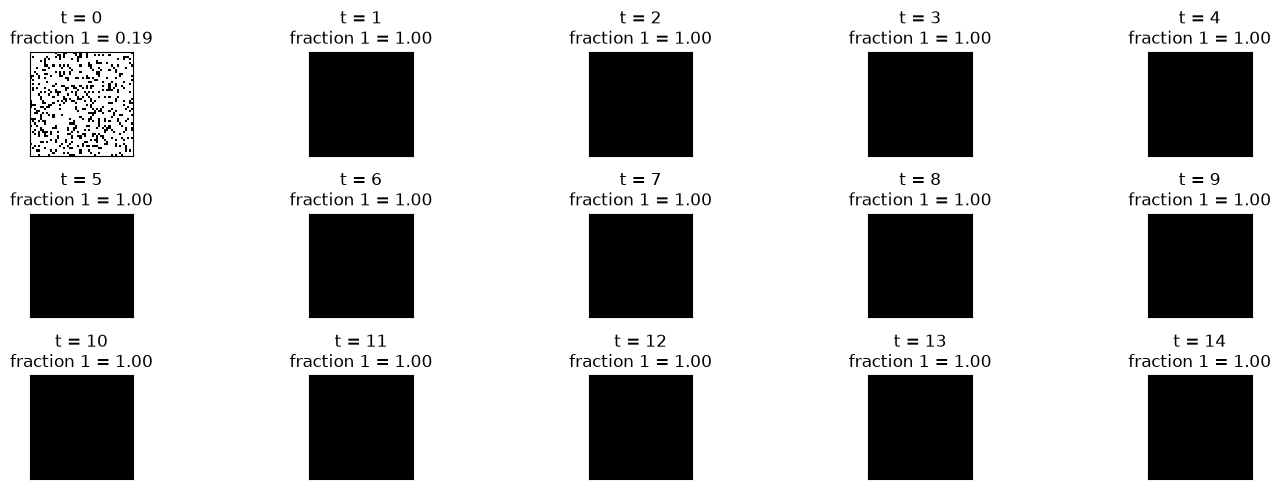

In [14]:
grid = Grid(
    width=50,
    height=50,
    theta=2,
    gamma=2,
    s=0.5,
    u1=5,
    u2=2,
    init_probs=0.2
)

steps = 15

fig, axes = plt.subplots(
    3, 5,
    figsize=(15, 5)
)

axes = axes.flatten()

for t in range(steps):

    axes[t].imshow(
        grid.state_array(),
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    axes[t].set_title(
        f"t = {t}\n"
        f"fraction 1 = {grid.fraction_on():.2f}"
    )

    axes[t].set_xticks([])
    axes[t].set_yticks([])

    # Move to the next timestep
    if t < steps:
        grid.step()

# Hide unused plots
for ax in axes[steps + 1:]:
    ax.axis("off")

plt.tight_layout()
plt.show()